# Web Scraping
---
In today's lab, we are going to download data from the internet using an API. API stands for **a**pplication **p**rogramming **i**nterface. Companies often create APIs as a way to allow users to more directly interact with their servers to retrieve data. Today, we are going to be using Twitter's API to download tweets to get some experience with larger datasets.

In [1]:
# Run this cell to set up your notebook
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import warnings

# These are the utility functions in the twitter_utils.py file
import twitter_utils as tu

# Ensure that Pandas shows at least 280 characters in columns, so we can see full tweets
pd.set_option('max_colwidth', 280)

%matplotlib inline
import re
import json

## Setup
---
For this lab, we will be importing utility functions to interact with Twitter's API. Underneath the hood, these utility functions use the `tweepy` package, which is the how you can interface with Twitter's API using `python`. First, we need to install `tweepy` so that our utility functions will be able to use use it. If you have time at the end of this lab, you can look in the `twitter_utils.py` file in this folder and try to understand how the utility functions work.

In [2]:
!pip install tweepy

Twitter requires you to have authentication keys to access their API.  To get your keys, you'll have to sign up for a Twitter developer account. Note that **anyone who has your authentication keys can post as you**. In order to protect your keys, you will be storing them in a separate file, which we have called `keys.json`, and reading them into this notebook from that file. Also note that **Twitter limits developers to a certain rate of data requests**. This means that if you make too many API calls in a short period of time, Twitter may block you from retrieving data for a certain period of time. Avoid rerunning cells that retrieve new tweets.

Follow the instructions below to get your Twitter API keys.  **Read the instructions completely before starting.**

1. [Create a Twitter account](https://twitter.com).  You can use an existing account if you have one; if you prefer to not do this assignment under your regular account, feel free to create a throw-away account.
2. Under account settings, add your phone number to the account.
3. [Create a Twitter developer account](https://dev.twitter.com/resources/signup) by clicking the 'Apply' button on the top right of the page. Attach it to your Twitter account. You'll have to fill out a form describing what you want to do with the developer account. Explain that you are doing this for a class at UC Berkeley and that you don't know exactly what you're building yet and just need the account to get started. These applications are approved by some sort of AI system, so it doesn't matter exactly what you write.
4. Once you're logged into your developer account, [create an application for this assignment](https://apps.twitter.com/app/new).  You can call it whatever you want, and you can write any URL when it asks for a web site.  You don't need to provide a callback URL.
5. On the page for that application, find your Consumer Key and Consumer Secret.
6. On the same page, create an Access Token.  Record the resulting Access Token and Access Token Secret.
7. Edit the file `keys.json` in the same folder as this file and replace the placeholders with your keys.

Now you should be all ready to go! Let's test that you have correctly set up your developer account and the `keys.json` folder. The following cell loads your keys into this notebook, then validates them with the Twitter API. It should display your Twitter username without any warnings.

In [12]:
import json
key_file = "monicas_keys.json" #Change to "keys.json" in final version.

# Loading your keys from keys.json
with open(key_file) as f:
    keys = json.load(f)
# if you print or view the contents of keys be sure to delete the cell!

# Validate keys.
# If your notebook does not print out "The keys are valid. Your username is: <your username>"
# you may have copied and pasted your keys incorrectly.
tu.validate_authentication(keys)

The keys are valid. Your username is: data100mw


If you are getting any errors in this cell, ask a TA for help. If you do not have valid keys, you will not be able to use the API.

## Downloading Tweets
---
Now we should be ready to download some tweets! In the following cell, we use one of the utility functions to download recent tweets with the hashtag "#data". This cell can take a few minutes to finish running.

In [13]:
# Note that you do not write the actual hashtag symbol
data = tu.download_recent_tweets_by_hashtag(hashtag = "urban", keys = keys)

NameError: name 'TweepError' is not defined

In [9]:
with open('urban_tweets.json', 'w') as fout:
    json.dump(data, fout)

In [10]:
test = pd.read_json('suburbia_tweets.json')
test

,contributors,coordinates,created_at,entities,extended_entities,favorite_count,favorited,geo,id,id_str,...,quoted_status,quoted_status_id,quoted_status_id_str,retweet_count,retweeted,retweeted_status,source,text,truncated,user
0,NaN,None,2019-04-08 20:55:38,"{'hashtags': [], 'symbols': [], 'user_mentions': [], 'urls': [{'url': 'https://t.co/tagGrBObmY', 'expanded_url': 'https://twitter.com/i/web/status/1115357555881054208', 'display_url': 'twitter.com/i/web/status/1…', 'indices': [117, 140]}]}",NaN,0,False,None,1115357555881054208,1115357555881054208,...,NaN,NaN,NaN,0,False,NaN,"<a href=""https://ifttt.com"" rel=""nofollow"">IFTTT</a>","Every moment of life is unique - a kiss, a sunset, a dance, a joke. None will ever recur in quite the same way. Eac… https://t.co/tagGrBObmY",True,"{'id': 526854377, 'id_str': '526854377', 'name': 'Justin Mede', 'screen_name': 'Justin_Mede', 'location': 'Vancouver, BC', 'description': 'Proud Father - Experienced Entrepreneur - Gentleman Adventurer', 'url': None, 'entities': {'description': {'urls': []}}, 'protected': Fal..."
1,NaN,None,2019-04-08 19:58:13,"{'hashtags': [{'text': 'sopeaceful', 'indices': [82, 93]}, {'text': 'mondayvibes', 'indices': [94, 106]}], 'symbols': [], 'user_mentions': [], 'urls': [{'url': 'https://t.co/eC7AoLfKUO', 'expanded_url': 'https://twitter.com/i/web/status/1115343105333628930', 'display_url': 't...",NaN,0,False,None,1115343105333628930,1115343105333628928,...,NaN,NaN,NaN,0,False,NaN,"<a href=""http://instagram.com"" rel=""nofollow"">Instagram</a>",Beautiful afternoon to walk along the sound before picking up Maddie from school! #sopeaceful #mondayvibes… https://t.co/eC7AoLfKUO,True,"{'id': 63234902, 'id_str': '63234902', 'name': 'Nami Tran', 'screen_name': 'naminatrix', 'location': 'NYC', 'description': 'Southern girl living in the big city', 'url': None, 'entities': {'description': {'urls': []}}, 'protected': False, 'followers_count': 45, 'friends_count..."
2,NaN,None,2019-04-08 15:21:04,"{'hashtags': [], 'symbols': [], 'user_mentions': [{'screen_name': 'eastcitybooks', 'name': 'East City Bookshop', 'id': 4835471192, 'id_str': '4835471192', 'indices': [49, 63]}, {'screen_name': 'amandakhurley', 'name': 'Amanda Kolson Hurley', 'id': 24099041, 'id_str': '2409904...",NaN,7,False,None,1115273359938469888,1115273359938469888,...,NaN,NaN,NaN,0,False,NaN,"<a href=""http://twitter.com/download/iphone"" rel=""nofollow"">Twitter for iPhone</a>","Just picked up my copy of “Radical Suburbs” from @eastcitybooks. Congrats, @amandakhurley—it looks great.… https://t.co/VbtjwdFmnX",True,"{'id': 16016618, 'id_str': '16016618', 'name': 'Jennifer Howard', 'screen_name': 'JenHoward', 'location': 'D.C.', 'description': 'Writer, editor, gadabout. @washingtonpost and @chronicle alum. At work on a history of clutter (forthcoming from @belt_publishing in fall 2020).',..."
3,NaN,None,2019-04-08 11:55:01,"{'hashtags': [{'text': 'suburbia', 'indices': [72, 81]}, {'text': 'art', 'indices': [82, 86]}, {'text': 'Ireland', 'indices': [87, 95]}], 'symbols': [], 'user_mentions': [], 'urls': [{'url': 'https://t.co/LHH5kNZX73', 'expanded_url': 'https://twitter.com/i/web/status/11152215...",NaN,2,False,None,1115221505632350208,1115221505632350208,...,NaN,NaN,NaN,0,False,NaN,"<a href=""https://buffer.com"" rel=""nofollow"">Buffer</a>","Moonrider - Café in the Sky, Finglas, Dublin (2004)\n\nby Tatsurou Bashi\n\n#suburbia #art #Ireland… https://t.co/LHH5kNZX73",True,"{'id': 1615542260, 'id_str': '1615542260', 'name': '2ha', 'screen_name': '2ha_magazine', 'location': 'Dublin', 'description': 'An independent magazine interested in the suburbs. For contributors, advertisers or stern letter writers contact editor@2ha.ie. Published by @type_ie..."
4,NaN,None,2019-04-08 06:23:33,"{'hashtags': [{'text': 'JackGrisham', 'indices': [0, 12]}, {'text': 'TSOL', 'indices': [13, 18]}, {'text': 'losanarchyradio', 'indices': [40, 56]}, {'text': 'kxlu', 'indices': [57, 62]}, {'text': 'punkrockbowling', 'indices': [63, 

We now have `data` assigned to a list with each element corresponding to a tweet. Let's examine one of these elements to get a better understanding of our data.

In [10]:
# This accesses the first (zero index) element of the list
data[0]

{'contributors': None,
 'coordinates': None,
 'created_at': 'Mon Apr 08 17:36:38 +0000 2019',
 'entities': {'hashtags': [{'indices': [20, 35], 'text': 'Gentrification'}],
  'symbols': [],
  'urls': [],
  'user_mentions': [{'id': 3320061177,
    'id_str': '3320061177',
    'indices': [3, 18],
    'name': 'Robin G',
    'screen_name': 'Capitol_Oyster'}]},
 'favorite_count': 0,
 'favorited': False,
 'geo': None,
 'id': 1115307476897820672,
 'id_str': '1115307476897820672',
 'in_reply_to_screen_name': None,
 'in_reply_to_status_id': None,
 'in_reply_to_status_id_str': None,
 'in_reply_to_user_id': None,
 'in_reply_to_user_id_str': None,
 'is_quote_status': True,
 'lang': 'en',
 'metadata': {'iso_language_code': 'en', 'result_type': 'recent'},
 'place': None,
 'quoted_status_id': 1115281841215426560,
 'quoted_status_id_str': '1115281841215426560',
 'retweet_count': 1,
 'retweeted': False,
 'retweeted_status': {'contributors': None,
  'coordinates': None,
  'created_at': 'Mon Apr 08 16:49:04

This is an example of another `python` data structure called a *dictionary*. Dictionaries store *values* by associating them with a *key* rather than by an integer index. You can access the values stored in a dictionary using bracket notation just like a list. For example:

In [11]:
# In this dictionary, the keys are strings, and the values are all numbers
d = {'a': 1,
    'b': 2,
    'c': 3}

d['a']

1

### Data Cleaning
---
The dictionary we were looking at above is a little bit hard to interpret because there dictionaries nested inside of some our keys. We can look only at the first level of keys in our dictionary by using the `.keys()` method.

In [14]:
data[0].keys()
# You can also use .values() to access all of the values

dict_keys(['created_at', 'id', 'id_str', 'text', 'truncated', 'entities', 'metadata', 'source', 'in_reply_to_status_id', 'in_reply_to_status_id_str', 'in_reply_to_user_id', 'in_reply_to_user_id_str', 'in_reply_to_screen_name', 'user', 'geo', 'coordinates', 'place', 'contributors', 'retweeted_status', 'is_quote_status', 'quoted_status_id', 'quoted_status_id_str', 'retweet_count', 'favorite_count', 'favorited', 'retweeted', 'lang'])

The most relevant keys for what we will be doing today are `'text'` (which contains the body of the text), `'user'` (the user who posted the tweet),  `'created_at'` (which is the time that the tweet was posted), and `'retweet_count'` (which is the number of times a tweet was retweeted). We can convert this into a dataframe by simply passing it to the `pd.DataFrame()` function.

In [17]:
# This creates a new DataFrame using our data list. Each element in the list becomes
# a row in this DataFrame, and each key becomes a column. The value corresponding to
# each key and row pair goes into the data table.
df = pd.DataFrame(data)

# This indexes our desired columns out of the original DataFrame, then assigns the
# smaller DataFrame to our original DataFrame object.
df = df[['text', 'user', 'created_at', 'retweet_count']]
df.head()

,text,user,created_at,retweet_count
0,RT @Capitol_Oyster: #Gentrification rearing it’s ugly head again. Who moves to the center of Shaw &amp; then decides it’s too loud?! I loved he…,"{'id': 940421131596595200, 'id_str': '940421131596595200', 'name': 'Lexie Sturm', 'screen_name': 'Lex_in_the_lab', 'location': 'Fort Pierce, FL', 'description': 'Ph.D. student+@NSFGRFP fellow in @VossLaboratory at @HarborBranch Coral Connectivity, Mesophotic Reef Ecology, Ma...",Mon Apr 08 17:36:38 +0000 2019,1
1,Check out the 8.1 Gentrification and Heritage Conservation Issue on ---&gt; https://t.co/DTXPcM2sLw… https://t.co/08KBNNrSxP,"{'id': 839896934974386176, 'id_str': '839896934974386176', 'name': 'Change Over Time Journal', 'screen_name': 'ChangeTimeJourn', 'location': '', 'description': 'A semiannual journal that publishes original, peer-reviewed papers on the history, theory, and praxis of conservati...",Mon Apr 08 17:27:09 +0000 2019,0
2,RT @JPenoCheddy: .@TMobile let Donald Campbell and his @MetroByTMobile store continue to play #gogo ! You shouldn't have to listen to a ge…,"{'id': 23542662, 'id_str': '23542662', 'name': 'Melissa', 'screen_name': 'girlygirlmel', 'location': 'Annapolis, MD', 'description': 'Designer, event specialist, and history aficionado.', 'url': None, 'entities': {'description': {'urls': []}}, 'protected': False, 'followers_c...",Mon Apr 08 17:10:48 +0000 2019,1
3,"A new study shows where #gentrification is becoming a crisis, pushing out and displacing African Americans who have… https://t.co/AmmCYtNZKF","{'id': 19543987, 'id_str': '19543987', 'name': 'Spotlight on Poverty', 'screen_name': 'povertynews', 'location': 'Washington, DC', 'description': 'Daily poverty news and commentaries from across the political spectrum. Sign up for our weekly newsletter: https://t.co/BaLcoio1n...",Mon Apr 08 17:01:12 +0000 2019,0
4,#Gentrification rearing it’s ugly head again. Who moves to the center of Shaw &amp; then decides it’s too loud?! I love… https://t.co/q3je11vK33,"{'id': 3320061177, 'id_str': '3320061177', 'name': 'Robin G', 'screen_name': 'Capitol_Oyster', 'location': 'Washington, DC', 'description': 'Marine science #scicomm & #scipol. DC - Miami - Charleston - DC. Into #WomeninSTEM, #DCStatehood, #LGBTQ, etc. Tweets are my own, retwe...",Mon Apr 08 16:49:04 +0000 2019,1


Unfortunately, Twitter by default does not attach geographic data to the metadata of each tweet. To get around this, we can use the location associated to the account of each poster. The code for the folloiwng section was adapted from this [source](http://www.mikaelbrunila.fi/2017/03/27/scraping-extracting-mapping-geodata-twitter/).

In [20]:
# Create an empty list.
tweets_and_locations_list = list()

for tweet in data:
    # Create an empty dictionary.
    new_entry = {}
    # Create a new key ('tweet') and assign it to the text of a particular tweet.
    new_entry['tweet'] = tweet['text']
    # Create a new key ('location') and assign it to the location of the user who
    # wrote that tweet.
    new_entry['location'] = tweet['user']['location']
    # Append the dictionary as another element of our list.
    tweets_and_locations_list.append(new_entry)
    
# Transform our list into a DataFrame. As before, each element of the list becomes
# a row in the DataFrame, and each key becomes a column.
tweets_and_locations = pd.DataFrame(tweets_and_locations_list)

# Display the first 10 tweets.
tweets_and_locations.head(10)

,location,tweet
0,"Fort Pierce, FL",RT @Capitol_Oyster: #Gentrification rearing it’s ugly head again. Who moves to the center of Shaw &amp; then decides it’s too loud?! I loved he…
1,,Check out the 8.1 Gentrification and Heritage Conservation Issue on ---&gt; https://t.co/DTXPcM2sLw… https://t.co/08KBNNrSxP
2,"Annapolis, MD",RT @JPenoCheddy: .@TMobile let Donald Campbell and his @MetroByTMobile store continue to play #gogo ! You shouldn't have to listen to a ge…
3,"Washington, DC","A new study shows where #gentrification is becoming a crisis, pushing out and displacing African Americans who have… https://t.co/AmmCYtNZKF"
4,"Washington, DC",#Gentrification rearing it’s ugly head again. Who moves to the center of Shaw &amp; then decides it’s too loud?! I love… https://t.co/q3je11vK33
5,"Washington, DC",#DontMuteDC: #Gentrification strikes again! Someone w/ a stick up their butt is threatening to sue #MetroPCS on Geo… https://t.co/kXkK777HFr
6,,"#Gentrification is real! This is a Shaw staple - if you don't like it, why did you move here?? #dontmuteDC https://t.co/kYw3XysZ6P"
7,XChicagoland Maine,"Where It Hits, #Gentrification Hits Hard: Study ⁦@CityLab⁩\n—\nNCRC found 75% of #neighborhoods marked “hazardous” on… https://t.co/VlPqlFwLHb"
8,"w-a-s-h-i-n-g, t-o-n baby, DC!",.@TMobile let Donald Campbell and his @MetroByTMobile store continue to play #gogo ! You shouldn't have to listen… https://t.co/TE5WOxSJEV
9,,@_RebeccaHolland just read your article about committing property fraud. very greedy and illegal #gentrification #lifestyles


Clearly this isn't a foolproof method, since the location associated with an account may have little bearing on the actual location from which a tweet was posted. Also, not all users have a location connected to their account. Depending on the data you have pulled from Twitter, you may also notice that some of the "locations" are not actually real places. We can do a bit of data cleaning to filter out the rows that contain true locations. First, let's get rid of the rows that do not contain any text at all in the `location` column.

In [21]:
# Create an empty DataFrame with the columns 'location' and 'tweet'
no_empties = pd.DataFrame(columns = ['location', 'tweet'])
for i in range(len(tweets_and_locations)):
    # This filters out tweets whose location column is an empty string.
    if tweets_and_locations.loc[i, "location"] != '':
        no_empties = no_empties.append(tweets_and_locations.loc[i,:])
no_empties.head(10)

,location,tweet
0,"Fort Pierce, FL",RT @Capitol_Oyster: #Gentrification rearing it’s ugly head again. Who moves to the center of Shaw &amp; then decides it’s too loud?! I loved he…
2,"Annapolis, MD",RT @JPenoCheddy: .@TMobile let Donald Campbell and his @MetroByTMobile store continue to play #gogo ! You shouldn't have to listen to a ge…
3,"Washington, DC","A new study shows where #gentrification is becoming a crisis, pushing out and displacing African Americans who have… https://t.co/AmmCYtNZKF"
4,"Washington, DC",#Gentrification rearing it’s ugly head again. Who moves to the center of Shaw &amp; then decides it’s too loud?! I love… https://t.co/q3je11vK33
5,"Washington, DC",#DontMuteDC: #Gentrification strikes again! Someone w/ a stick up their butt is threatening to sue #MetroPCS on Geo… https://t.co/kXkK777HFr
7,XChicagoland Maine,"Where It Hits, #Gentrification Hits Hard: Study ⁦@CityLab⁩\n—\nNCRC found 75% of #neighborhoods marked “hazardous” on… https://t.co/VlPqlFwLHb"
8,"w-a-s-h-i-n-g, t-o-n baby, DC!",.@TMobile let Donald Campbell and his @MetroByTMobile store continue to play #gogo ! You shouldn't have to listen… https://t.co/TE5WOxSJEV
10,Global,RT @ninak612: Governing entities are marketing #gentrification by rebranding it as #OpportunityZones I bet the people who’ve built somethin…
11,Global,RT @CJAOurPower: Industry City: A #GreenNewDeal Vs. #Gentrification in Sunset Park: https://t.co/UsnvQ9nPGU https://t.co/AXj88fbPhN
12,Global,RT @JeffFrazier: Goodbye Nashville. The N.F.L.’s Great Cherry Tree Caper https://t.co/GRFyUeWVcT #criminal #gentrification


This looks pretty good! We would still like to filter through our locations for places that actually exist. Let's use the `.groupby()` method to take a look at what locations we have in our data.

In [22]:
no_empties.groupby('location').count()

,tweet
location,
"#10 156 St Albert Trail, \nSt Albert, AB T8N 0P5",1
#Decolonize,2
#Huntsville #Alabama,1
#SayHerName#WalkTogether,1
"1.372609,103.849407",1
10115 Berlin Mitte,1
5 Caledonian Road,1
503,1
???,1


If you scroll through this list, you will likely see a whole litany of "locations" that do not resemble locations, from things like phone numbers, to IP addresses, to emojis. You may even see locations in other languages! We do not have time to day to sort through all of these right now, so we are goign to move on to a few other techniques that we can use to analyze these kinds of data.

### Scraping Tweets by Location
---
Since many of these tweets do not have useful locations, we may want to filter by location when we ask the API for tweets. We can use the same function as before, using the optional `location` argument. The format of the location argument is `"latitude,longitude,radius"`.

In [7]:
berkeley_data = tu.download_recent_tweets_by_hashtag("gentrification", keys, "37.829314,-122.264433,5km")

TypeError: download_recent_tweets_by_hashtag() takes 2 positional arguments but 3 were given

### Temporal Data
---
Another facet of the tweets that you may want to analyze is the time at which they were posted. Currently, the only way we have information about the time the tweets were posted is in the `'created_at'` column, which is a string. As you may remember from the Introductory lab, `python` compares strings by assigning values to the letters themselves based on their position in the alphabet. We want to convert these strings to `datetime` objects, which will tell `python` at what time tweets were posted.

In [23]:
df['time'] = pd.to_datetime(df['created_at'])
df['time'].head()

0   2019-04-08 17:36:38+00:00
1   2019-04-08 17:27:09+00:00
2   2019-04-08 17:10:48+00:00
3   2019-04-08 17:01:12+00:00
4   2019-04-08 16:49:04+00:00
Name: time, dtype: datetime64[ns, UTC]

Now that each string has been converted into a `datetime` object, we can extract the day, hour, minute, etc. of each time point like so

In [24]:
df.loc[0, 'time'].day

8

In [25]:
df.loc[0, 'time'].hour

17

In [26]:
df.loc[0, 'time'].minute

36

Notice that we are not adding parentheses at the end of each line. That is because the `.day`, `.hour`, and `.minute` are not *functions* we are calling, but rather *attributes* of the particular `datetime` object. If we want to look at the time of day that people tend to tweet about #data, we can extract these attributes.

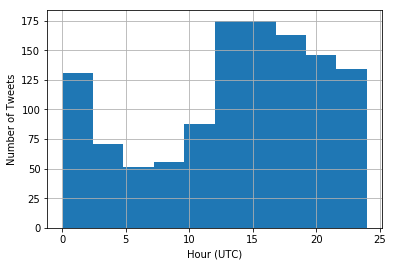

In [27]:
df['hour'] = [df.loc[i, 'time'].hour + df.loc[i, 'time'].minute/60 + df.loc[i, 'time'].second/3600 for i in range(len(df))]
df['hour'].hist()
plt.xlabel("Hour (UTC)")
plt.ylabel("Number of Tweets");

**Question:** What observations or trends do you notice about this graph?

YOUR ANSWER HERE

**Question:** What could be improved about this graph or the process we used to obtain the data that generated it?

YOUR ANSWER HERE

### Sentiment Analysis
---
We can use the words the tweets to measure the sentiment, or the positive/negative feeling generated by the tweet. To do so we will be using the [VADER (Valence Aware Dictionary and sEntiment Reasoner)](https://github.com/cjhutto/vaderSentiment), which is a rule-based sentiment analysis tool specifically designed for social media. It even includes emojis! Run the following cell to load in the lexicon.

In [7]:
vader = tu.load_vader()
vader

AttributeError: module 'twitter_utils' has no attribute 'load_vader'

All of the words in `vader` are all lowercase, while many of our tweets are not. We need to modify the text in the tweets so that the words in our tweets will match up with the words stored in `vader`. Additionally, we need to remove punctuation since that will cause the words to not match up as well. We will put these modified tweets into another column in our DataFrame so that we can still have access to them later.

In [16]:
test.columns

Index(['contributors', 'coordinates', 'created_at', 'entities',
       'extended_entities', 'favorite_count', 'favorited', 'geo', 'id',
       'id_str', 'in_reply_to_screen_name', 'in_reply_to_status_id',
       'in_reply_to_status_id_str', 'in_reply_to_user_id',
       'in_reply_to_user_id_str', 'is_quote_status', 'lang', 'metadata',
       'place', 'possibly_sensitive', 'quoted_status', 'quoted_status_id',
       'quoted_status_id_str', 'retweet_count', 'retweeted',
       'retweeted_status', 'source', 'text', 'truncated', 'user'],
      dtype='object')

In [18]:
df = test[['id', 'text', 'retweet_count']]
df.set_index('id')
df['cleaned'] = tu.clean_tweets(df['text'])
df



NameError: name 're' is not defined